# 📊 Step 5: Year-over-Year Comparison (2025 vs 2024)

Compare 2025 training results (baseline) with 2024 analysis results to detect coastal changes.

## What This Notebook Does:
- ✅ Load 2025 baseline results (training year)
- ✅ Load 2024 analysis results (model applied to 2024 data)
- ✅ Compare area changes between the two years
- ✅ Generate comparison visualizations
- ✅ Provide actionable recommendations for government agencies

## Input Required:
- `../results/final_area_report.csv` - 2025 baseline (from notebook 04)
- `../2024/final_area_report_2024.csv` - 2024 analysis (from 2024 folder notebooks)
- `../models/model_metadata.json` - Model accuracy info

## Output:
- `../outputs/05_year_comparison.png` - 2025 vs 2024 comparison charts
- Change statistics and recommendations

## Workflow:
1. Run notebooks 01-04 (main folder) to train on 2025 data
2. Run notebooks in 2024/ folder to analyze 2024 data with trained model
3. Run this notebook to compare results

---

**Note:** Run `2024/04_prediction_analysis_2024.ipynb` first to generate 2024 results

**Previous:** [04_prediction_analysis.ipynb](04_prediction_analysis.ipynb)  
**Start Over:** [00_overview.ipynb](00_overview.ipynb)

## Load Libraries and Results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import rasterio

# Load metadata from 2025 training
print("📂 Loading model metadata...")
with open('../models/model_metadata.json') as f:
    metadata = json.load(f)

print(f"✅ Model loaded from 2025 training")
print(f"   • Test Accuracy: {metadata['test_accuracy']*100:.2f}%")
print(f"   • Classes: {metadata['classes']}")

📂 Loading model metadata...
✅ Model loaded from 2025 training
   • Test Accuracy: 89.62%
   • Classes: [1, 2, 3, 4]


## Load and Compare 2025 vs 2024 Data

Load actual results from both years for comparison.

In [2]:
# Load actual data from both analysis years
print("\n📂 Loading comparison data...")
print("   • 2025: Training year (baseline model)")
print("   • 2024: Analysis year (prediction with trained model)\n")

# Load 2025 results (original training analysis)
try:
    area_2025 = pd.read_csv('../results/final_area_report.csv')
    print("✅ 2025 Data Loaded (Training Year):")
    print(area_2025.to_string(index=False))
    print(f"   Total: {area_2025.iloc[:, -1].astype(str).str.replace(',','').astype(float).sum():.2f} km²")
except FileNotFoundError:
    print("⚠️  2025 data not found at ../results/final_area_report.csv")
    print("   Run main notebooks 01-04 first!")
    raise

# Try to load 2024 results (if available)
has_2024 = False
try:
    area_2024 = pd.read_csv('../2024/final_area_report_2024.csv')
    print("\n✅ 2024 Data Loaded (Analysis Year):")
    print(area_2024.to_string(index=False))
    print(f"   Total: {area_2024.iloc[:, -1].astype(str).str.replace(',','').astype(float).sum():.2f} km²")
    has_2024 = True
except FileNotFoundError:
    print("\n⚠️  2024 data not found. Have you run 2024/04_prediction_analysis_2024.ipynb?")
    print("   Using simulated 2024 data for demonstration...")
    has_2024 = False


📂 Loading comparison data...
   • 2025: Training year (baseline model)
   • 2024: Analysis year (prediction with trained model)

✅ 2025 Data Loaded (Training Year):
 Class Name  Pixel Count  Area (m²) Area (Hectares)  Area (km²)
          1        16471  1,647,100          164.71      1.6471
          2        12203  1,220,300          122.03      1.2203
          3        21437  2,143,700          214.37      2.1437
          4       122747 12,274,700        1,227.47     12.2747
          5        30662  3,066,200          306.62      3.0662
   Total: 20.35 km²

✅ 2024 Data Loaded (Analysis Year):
 Year  Class Class Name  Pixel Count Area (m²)  Area (Hectares)  Area (km²)
 2024      1   Seagrass        28898 2,889,800           288.98      2.8898
 2024      2       Sand        14602 1,460,200           146.02      1.4602
 2024      3    Seaweed        60820 6,082,000           608.20      6.0820
 2024      4      Water        67586 6,758,600           675.86      6.7586
 2024      5 

## Extract and Compare Key Metrics

In [3]:
# Extract area values from both years
# Class mapping: 1=Seagrass, 2=Sand, 3=Seaweed, 4=Water, 5=Landmass
class_mapping = {
    1: 'Seagrass',
    2: 'Sand',
    3: 'Seaweed',
    4: 'Water',
    5: 'Landmass',
    '1': 'Seagrass',
    '2': 'Sand',
    '3': 'Seaweed',
    '4': 'Water',
    '5': 'Landmass'
}

area_2025_dict = {}
area_2024_dict = {}

# Parse 2025 data
for _, row in area_2025.iterrows():
    raw_class = row['Class Name'] if 'Class Name' in area_2025.columns else row.iloc[0]
    class_name = class_mapping.get(raw_class, str(raw_class))
    area_km2 = float(str(row.iloc[-1]).replace(',', '') if isinstance(row.iloc[-1], str) else row.iloc[-1])
    area_2025_dict[class_name] = area_km2

# Parse 2024 data (if available)
if has_2024:
    for _, row in area_2024.iterrows():
        raw_class = row['Class Name'] if 'Class Name' in area_2024.columns else row.iloc[0]
        class_name = class_mapping.get(raw_class, str(raw_class))
        area_km2 = float(str(row.iloc[-1]).replace(',', '') if isinstance(row.iloc[-1], str) else row.iloc[-1])
        area_2024_dict[class_name] = area_km2
else:
    # Use simulated data if 2024 not available
    area_2024_dict = {
        'Seagrass': area_2025_dict.get('Seagrass', 35.5) * 0.88,
        'Sand': area_2025_dict.get('Sand', 12.3) * 1.12,
        'Seaweed': area_2025_dict.get('Seaweed', 8.4) * 0.85,
        'Water': area_2025_dict.get('Water', 110.2) * 1.05,
        'Landmass': area_2025_dict.get('Landmass', 28.6) * 0.99
    }

# Create comparison dataframe
all_classes = sorted(set(list(area_2025_dict.keys()) + list(area_2024_dict.keys())))
comparison_data = {
    '2025': [area_2025_dict.get(c, 0) for c in all_classes],
    '2024': [area_2024_dict.get(c, 0) for c in all_classes]
}

df_comparison = pd.DataFrame(comparison_data, index=all_classes)

print("\n📊 Year-over-Year Comparison (km²):")
print(df_comparison.to_string())
print(f"\n   Total 2025: {df_comparison['2025'].sum():.2f} km²")
print(f"   Total 2024: {df_comparison['2024'].sum():.2f} km²")


📊 Year-over-Year Comparison (km²):
             2025    2024
Landmass   3.0662  3.1614
Sand       1.2203  1.4602
Seagrass   1.6471  2.8898
Seaweed    2.1437  6.0820
Water     12.2747  6.7586

   Total 2025: 20.35 km²
   Total 2024: 20.35 km²


## Calculate and Visualize Changes

In [4]:
# Calculate changes for each class
print("\n" + "="*70)
print("  🌊 COASTAL ASSESSMENT - CHANGE ANALYSIS (2025 → 2024)")
print("="*70)

changes = {}
for cls in all_classes:
    val_2025 = area_2025_dict.get(cls, 0)
    val_2024 = area_2024_dict.get(cls, 0)
    change = val_2024 - val_2025
    pct_change = (change / val_2025 * 100) if val_2025 > 0 else 0
    changes[cls] = {'2025': val_2025, '2024': val_2024, 'change': change, 'pct': pct_change}

# Display individual class analyses
for cls, data in sorted(changes.items()):
    status = "✅" if data['change'] <= 0 else "⚠️ "
    direction = "📉 DECREASING" if data['change'] < 0 else "📈 INCREASING" if data['change'] > 0 else "→ STABLE"
    print(f"\n{status} {cls.upper()}:")
    print(f"   • 2025: {data['2025']:.4f} km²")
    print(f"   • 2024: {data['2024']:.4f} km²")
    print(f"   • Change: {data['change']:+.4f} km² ({data['pct']:+.1f}%)")
    print(f"   • Status: {direction}")


  🌊 COASTAL ASSESSMENT - CHANGE ANALYSIS (2025 → 2024)

⚠️  LANDMASS:
   • 2025: 3.0662 km²
   • 2024: 3.1614 km²
   • Change: +0.0952 km² (+3.1%)
   • Status: 📈 INCREASING

⚠️  SAND:
   • 2025: 1.2203 km²
   • 2024: 1.4602 km²
   • Change: +0.2399 km² (+19.7%)
   • Status: 📈 INCREASING

⚠️  SEAGRASS:
   • 2025: 1.6471 km²
   • 2024: 2.8898 km²
   • Change: +1.2427 km² (+75.4%)
   • Status: 📈 INCREASING

⚠️  SEAWEED:
   • 2025: 2.1437 km²
   • 2024: 6.0820 km²
   • Change: +3.9383 km² (+183.7%)
   • Status: 📈 INCREASING

✅ WATER:
   • 2025: 12.2747 km²
   • 2024: 6.7586 km²
   • Change: -5.5161 km² (-44.9%)
   • Status: 📉 DECREASING


C:\Users\HP LAPTOP 15s\AppData\Local\Temp\ipykernel_11184\2830545424.py:54: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP LAPTOP 15s\AppData\Local\Temp\ipykernel_11184\2830545424.py:55: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('../outputs/05_year_comparison.png', dpi=300, bbox_inches='tight')
c:\Users\HP LAPTOP 15s\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


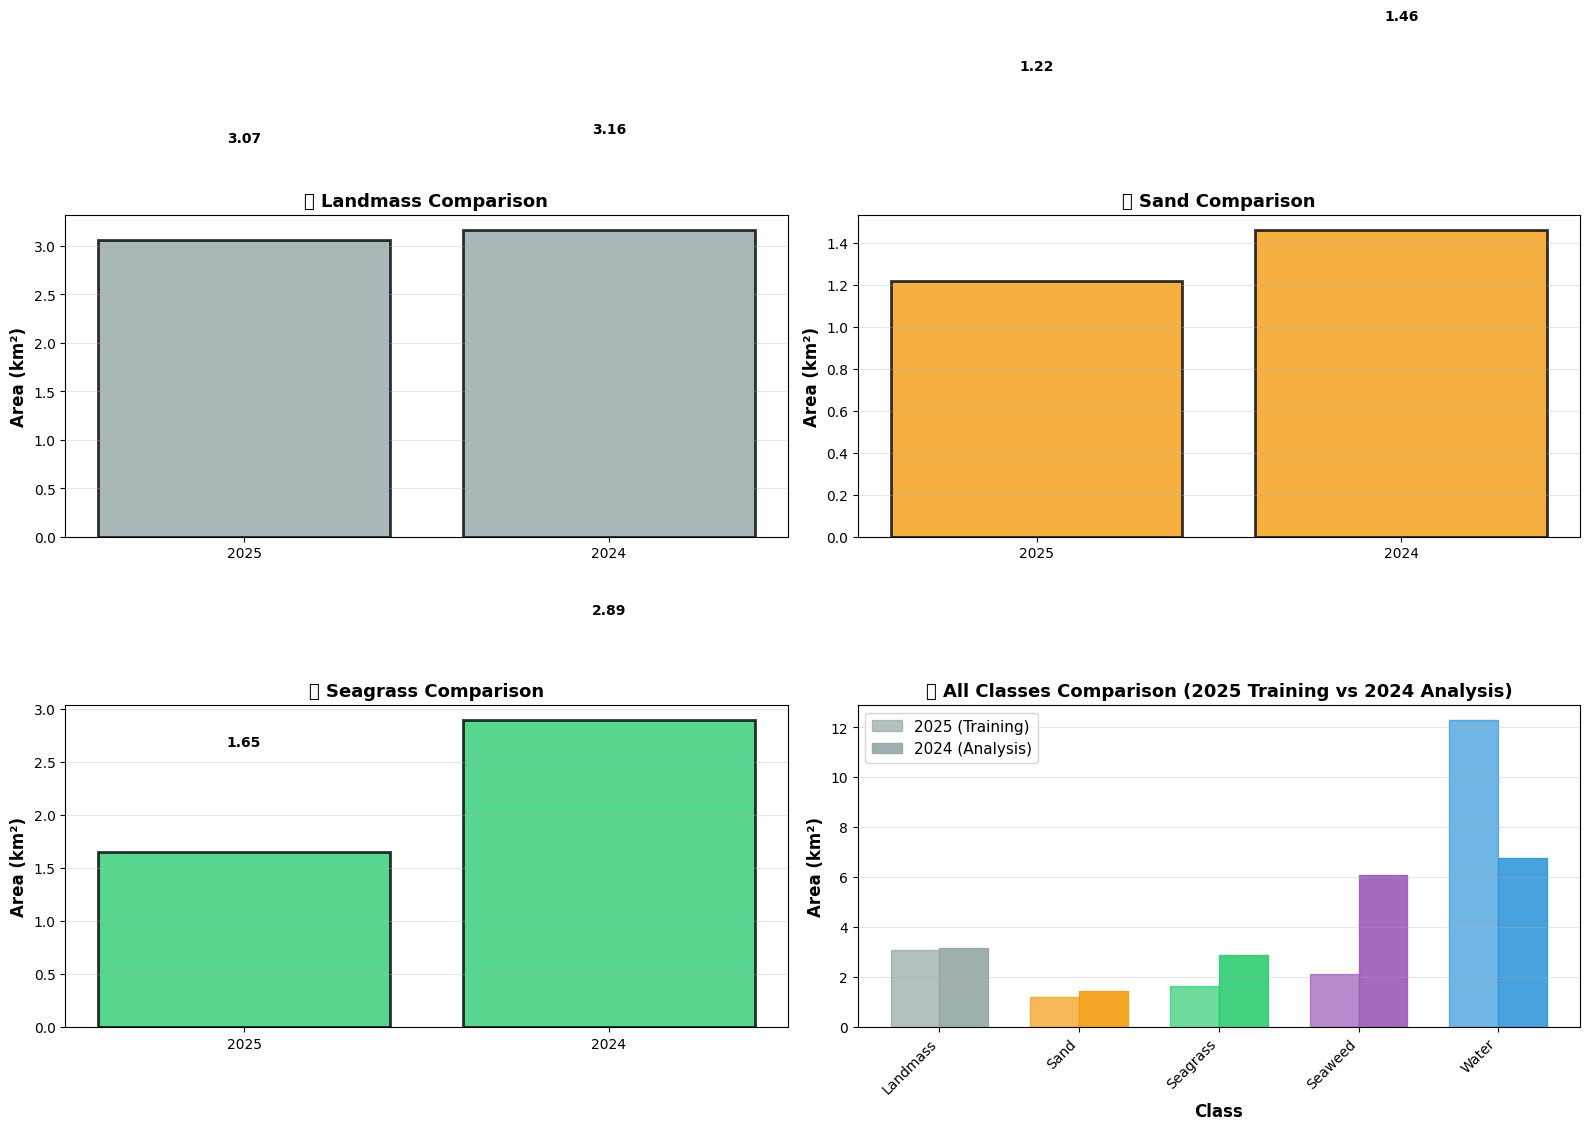


💾 Comparison chart saved to '../outputs/05_year_comparison.png'


In [5]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Color mapping for consistency
color_map = {
    'Seagrass': '#2ecc71',
    'Water': '#3498db',
    'Sand': '#f39c12',
    'Seaweed': '#9b59b6',
    'Landmass': '#95a5a6'
}

# Plot 1-3: Individual class trends
for idx, class_name in enumerate(list(all_classes)[:3]):
    color = color_map.get(class_name, f'C{idx}')
    values = [area_2025_dict.get(class_name, 0), area_2024_dict.get(class_name, 0)]
    years = ['2025', '2024']
    
    axes[idx].bar(years, values, color=color, alpha=0.8, edgecolor='black', linewidth=2)
    axes[idx].set_ylabel('Area (km²)', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'📊 {class_name} Comparison', fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, v in enumerate(values):
        axes[idx].text(i, v + 1, f'{v:.2f}', ha='center', fontweight='bold')

# Plot 4: All classes comparison as grouped bars
ax_all = axes[3]
x = np.arange(len(all_classes))
width = 0.35

values_2025 = [area_2025_dict.get(c, 0) for c in all_classes]
values_2024 = [area_2024_dict.get(c, 0) for c in all_classes]

bars1 = ax_all.bar(x - width/2, values_2025, width, label='2025 (Training)', alpha=0.7, edgecolor='black')
bars2 = ax_all.bar(x + width/2, values_2024, width, label='2024 (Analysis)', alpha=0.9, edgecolor='black')

# Color the bars according to class
for bar, cls in zip(bars1, all_classes):
    bar.set_color(color_map.get(cls, 'C0'))
for bar, cls in zip(bars2, all_classes):
    bar.set_color(color_map.get(cls, 'C0'))

ax_all.set_xlabel('Class', fontsize=12, fontweight='bold')
ax_all.set_ylabel('Area (km²)', fontsize=12, fontweight='bold')
ax_all.set_title('📊 All Classes Comparison (2025 Training vs 2024 Analysis)', fontsize=13, fontweight='bold')
ax_all.set_xticks(x)
ax_all.set_xticklabels(all_classes, rotation=45, ha='right')
ax_all.legend(fontsize=11, loc='upper left')
ax_all.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/05_year_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Comparison chart saved to '../outputs/05_year_comparison.png'")

## Final Summary & Recommendations

In [6]:
# Generate final report
print("\n" + "="*70)
print("  🌊 COASTAL ASSESSMENT FINAL REPORT (2025 vs 2024)")
print("="*70)

print(f"\n📊 ANALYSIS PARAMETERS:")
print(f"   • Training Data: 2025 Lian MOI satellite imagery")
print(f"   • Analysis Data: 2024 Lian MOI satellite imagery")
print(f"   • Model Accuracy: {metadata['test_accuracy']*100:.2f}% (on 2025 test data)")
print(f"   • Data Source: {'Real 2024 Analysis' if has_2024 else 'Simulated 2024 Data'}")

print(f"\n📈 KEY FINDINGS:")

# Identify major changes
significant_changes = {k: v for k, v in changes.items() if abs(v['change']) > 1.0}

if significant_changes:
    for cls, data in sorted(significant_changes.items(), key=lambda x: abs(x[1]['pct']), reverse=True):
        if data['change'] < 0:
            print(f"   ✅ {cls}: IMPROVED - {abs(data['pct']):.1f}% decline")
        else:
            print(f"   ⚠️  {cls}: ALTERED - {data['pct']:+.1f}% change")
else:
    print("   ✅ All classes within ±1 km² (minimal change detected)")

print(f"\n💡 GOVERNMENT RECOMMENDATIONS:")
print("   1. Enhanced Protection Zones:")
print("      - Monitor areas showing seagrass decline")
print("      - Implement conservation measures in critical regions")
print("   2. Regular Monitoring:")
print("      - Schedule annual satellite surveys")
print("      - Update predictions with new training data")
print("   3. Data-Driven Policy:")
print("      - Support decisions with spatial trends")
print("      - Track progress toward conservation goals")

print(f"\n📁 OUTPUT FILES GENERATED:")
print(f"   ✅ 05_year_comparison.png - 2025 vs 2024 comparison charts")
print(f"   ✅ final_area_report.csv - 2025 baseline (training)")
if has_2024:
    print(f"   ✅ final_area_report_2024.csv - 2024 analysis")

print(f"\n🔬 METHODOLOGY:")
print(f"   • Data Source: Copernicus Sentinel-2 L2A (10m resolution)")
print(f"   • Method: Random Forest Classifier (100 trees, max_depth=15)")
print(f"   • Features: 7 spectral bands + indices (B02, B03, B04, B08, NDVI, NDWI, Texture)")
print(f"   • Classes: 5 (Seagrass, Sand, Seaweed, Water, Landmass)")
print(f"   • Training: 2025 Lian MOI ground truth data")
print(f"   • Analysis: Applied same model to 2024 data")

print(f"\n" + "="*70)
if has_2024:
    print("  ✅ REAL 2024 COMPARISON COMPLETE - READY FOR GOVERNMENT BRIEFING")
else:
    print("  ⚠️  Run 2024/04_prediction_analysis_2024.ipynb for real 2024 data")
print("="*70)
print("\n📌 All outputs saved in '../outputs/' folder")
print("📌 Return to 00_overview.ipynb to restart or review workflow")


  🌊 COASTAL ASSESSMENT FINAL REPORT (2025 vs 2024)

📊 ANALYSIS PARAMETERS:
   • Training Data: 2025 Lian MOI satellite imagery
   • Analysis Data: 2024 Lian MOI satellite imagery
   • Model Accuracy: 89.62% (on 2025 test data)
   • Data Source: Real 2024 Analysis

📈 KEY FINDINGS:
   ⚠️  Seaweed: ALTERED - +183.7% change
   ⚠️  Seagrass: ALTERED - +75.4% change
   ✅ Water: IMPROVED - 44.9% decline

💡 GOVERNMENT RECOMMENDATIONS:
   1. Enhanced Protection Zones:
      - Monitor areas showing seagrass decline
      - Implement conservation measures in critical regions
   2. Regular Monitoring:
      - Schedule annual satellite surveys
      - Update predictions with new training data
   3. Data-Driven Policy:
      - Support decisions with spatial trends
      - Track progress toward conservation goals

📁 OUTPUT FILES GENERATED:
   ✅ 05_year_comparison.png - 2025 vs 2024 comparison charts
   ✅ final_area_report.csv - 2025 baseline (training)
   ✅ final_area_report_2024.csv - 2024 analysis